In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.shape

(918, 12)

In [ ]:
df.isnull().sum()  

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

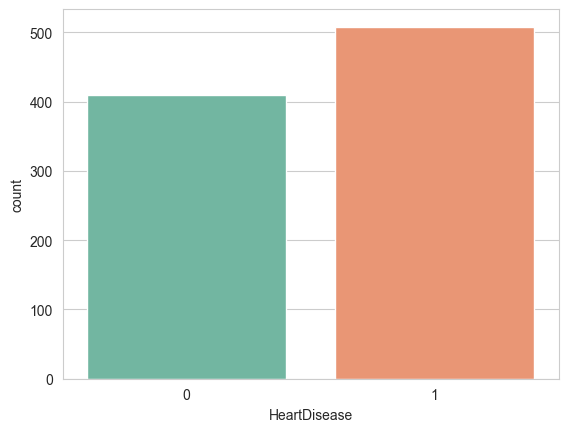

In [22]:
sns.set_style('whitegrid')
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.show()

<Axes: xlabel='HeartDisease', ylabel='Age'>

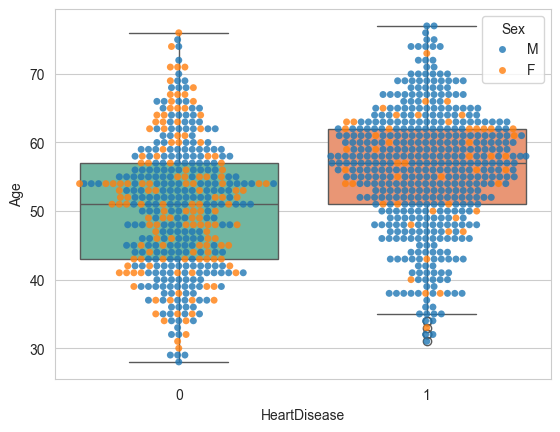

In [30]:
sns.boxplot(x='HeartDisease', y='Age', data=df, palette='Set2')
sns.swarmplot(x='HeartDisease', y='Age', data=df, alpha=0.8, hue = 'Sex')

- the median age for patients without heart disease is approx around 51-52, while for with heart disease is around 57-58.
- most of the people develop heart disease in the age range of 50-60. 
- there are younger outliers in the with heart disease graph, which means some young people in 30-40 age group also have heart diseases. 

<Axes: xlabel='Sex', ylabel='count'>

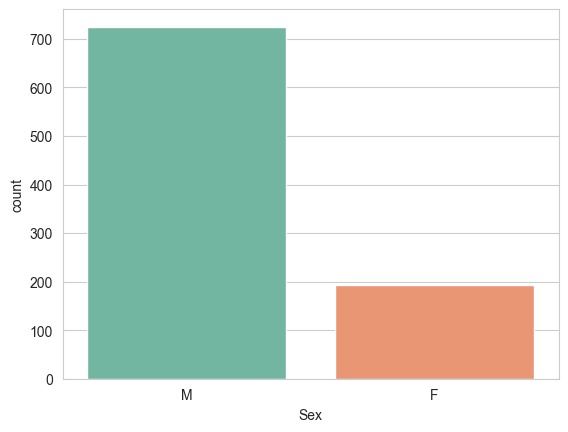

In [39]:
sns.countplot(x = 'Sex', data = df, palette='Set2')

the males in the dataset are much more in number than the no. of females.

In [32]:
df[df['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [33]:
df[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


cholestrol n resting bp cant be 0, so replacing 0s with the mean value.

In [34]:
df.replace({'Cholesterol': 0}, df['Cholesterol'].mean(), inplace=True)
df.replace({'RestingBP': 0}, df['RestingBP'].mean(), inplace=True)

<Axes: xlabel='ChestPainType', ylabel='count'>

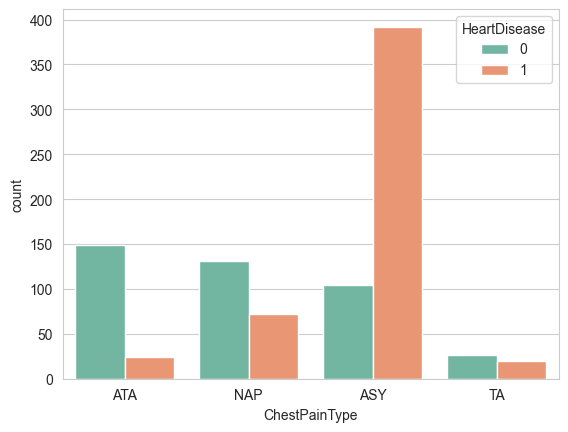

In [41]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'], palette='Set2')

ASY (Asymptomatic): It means the patient shows no outward symptoms of chest pain, yet this group has the highest count of heart disease 

ATA (Atypical Angina): Chest pain that doesn't fit the typical profile of heart issues. As the plot shows, people in this group are much more likely to be healthy (green bar) than have heart disease.

NAP (Non-Anginal Pain): Pain that is often unrelated to the heart (like acid reflux or muscle pain).

TA (Typical Angina): Classic chest pain caused by reduced blood flow to the heart (feeling of pressure or squeezing).

<Axes: xlabel='FastingBS', ylabel='count'>

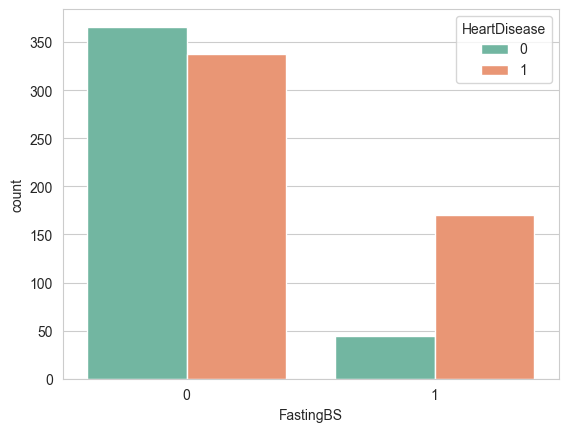

In [45]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'], palette='Set2')

- most of the patients have normal blood sugar. FastingBS = 0. 
- for most of the patients, if they dont have fastingbs, then they have slightly lesser risk of heart disease. 
- if they have fastingbs then the risk of heart disease is much more.

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

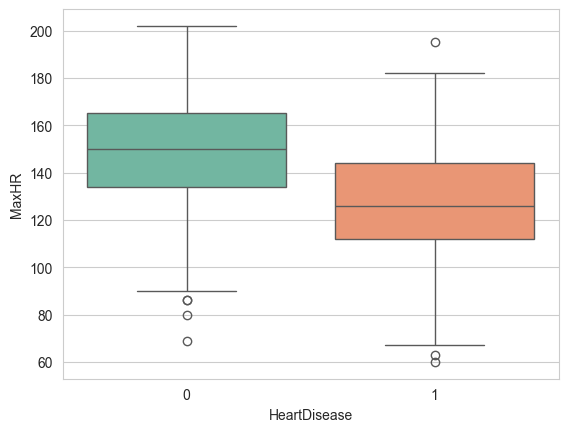

In [53]:
sns.boxplot(x = df['HeartDisease'], y = df['MaxHR'], palette='Set2')

if the heart rate is higher, then the risk of heart disease is lower.

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

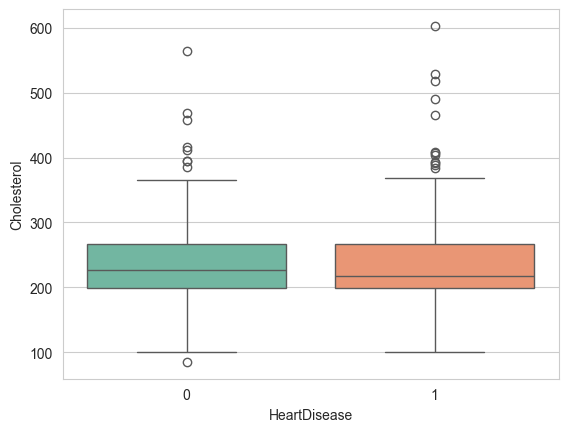

In [54]:
sns.boxplot(x = df['HeartDisease'], y = df['Cholesterol'], palette='Set2')

cholesterol on its own might not be as strong feature leading to heart disease. but its seen that there are slightly more outliers in 1(heart disease) which means higher cholestrol may lead to higher risk of heart disease (slightly)

<Axes: >

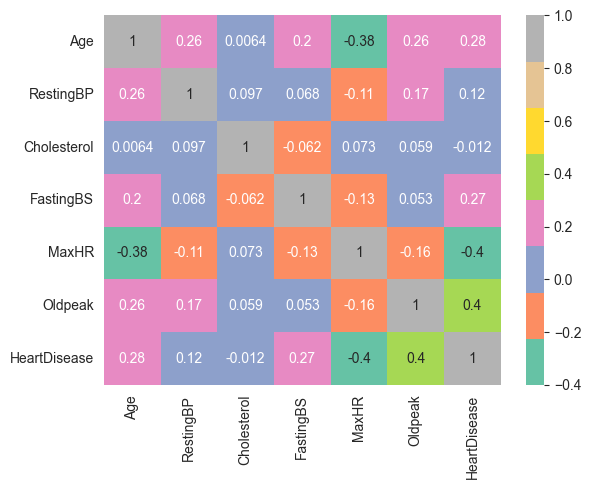

In [56]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Set2')

In [57]:
df_encoded = pd.get_dummies(df,drop_first=True)

In [58]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [59]:
df_encoded = df_encoded.astype(int)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [60]:
df_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [62]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
for k in range(1, 20, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    print(f"K={k}, Accuracy: {knn.score(X_test_scaled, y_test):.4f}")


K=1, Accuracy: 0.8098
K=3, Accuracy: 0.8315
K=5, Accuracy: 0.8641
K=7, Accuracy: 0.8696
K=9, Accuracy: 0.8696
K=11, Accuracy: 0.8750
K=13, Accuracy: 0.8641
K=15, Accuracy: 0.8641
K=17, Accuracy: 0.8641
K=19, Accuracy: 0.8641


In [80]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(n_neighbors=11),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

In [81]:
result = []

In [82]:
from sklearn.metrics import f1_score, recall_score

In [83]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    result.append({'Model': name, 
                   'Accuracy': round(acc, 4),
                   'f1 score': round(f1, 4), 
                   'recall': recall})

In [84]:
result

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8641,
  'f1 score': 0.8792,
  'recall': 0.8504672897196262},
 {'Model': 'KNN',
  'Accuracy': 0.875,
  'f1 score': 0.89,
  'recall': 0.8691588785046729},
 {'Model': 'Naive Bayes',
  'Accuracy': 0.8478,
  'f1 score': 0.8614,
  'recall': 0.8130841121495327},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8098,
  'f1 score': 0.8293,
  'recall': 0.794392523364486},
 {'Model': 'SVM',
  'Accuracy': 0.8478,
  'f1 score': 0.8654,
  'recall': 0.8411214953271028}]

the best model is knn. accuracy is highest. 

also, for heart disease pred, if a person has heart disease n its predicted as no heart disease then its risky. that means FN costly is risky. so here recall is imp. recall too is highest for knn.

In [87]:
import joblib 
joblib.dump(models['KNN'], 'KNN_heart_model.pkl')
joblib.dump(scaler, 'sc.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']